In [9]:
%pip install opencv-python

   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/44.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/44.0 MB ? eta -:--:--
    --------------------------------------- 0.8/44.0 MB 1.5 MB/s eta 0:00:29
   - -------------------------------------- 1.3/44.0 MB 1.8 MB/s eta 0:00:24
   - -------------------------------------- 1.8/44.0 MB 2.0 MB/s eta 0:00:21
   -- ------------------------------------- 2.6/44.0 MB 2.3 MB/s eta 0:00:18
   --- ------------------------------------ 3.4/44.0 MB 2.6 MB/s eta 0:00:16
   --- ------------------------------------ 4.2/44.0 MB 2.8 MB/s eta 0:00:15
   ---- ----------------------------------- 5.0/44.0 MB 2.9 MB/s eta 0:00:14
   ----- ---------------------------------- 6.0/44.0 MB 3.2 MB/s eta 0:00:12
   ----- ---------------------------------- 6.6/44.0 MB 3.2 MB/s eta 0:00:12
   ------ --------------------------------- 7.6/44.0 MB 3.3 MB/s eta 0:00:11
   ------- ---------

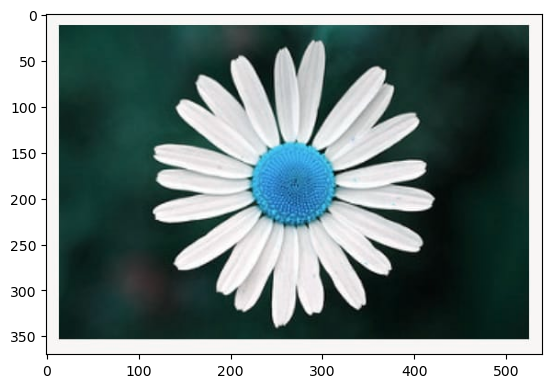

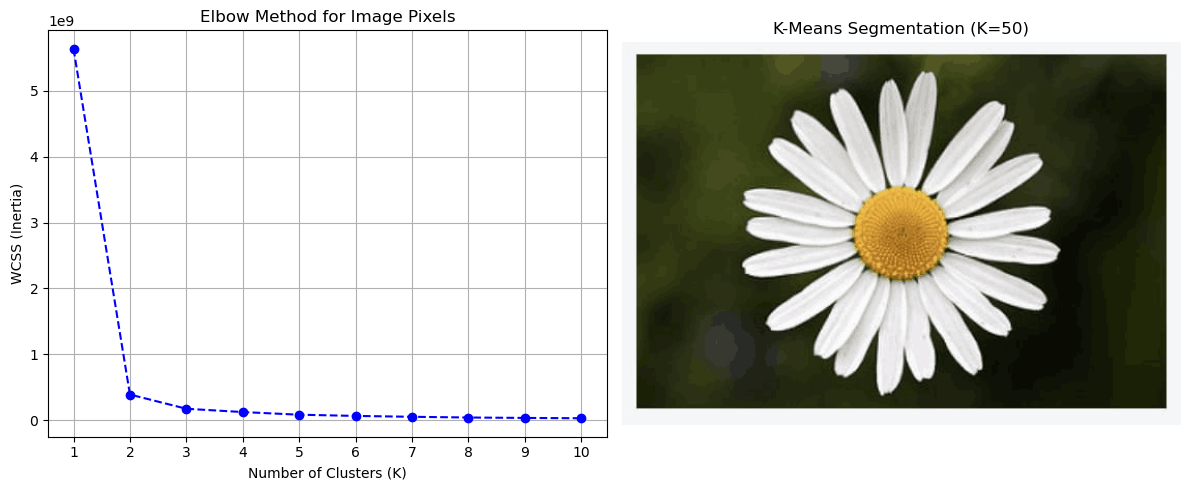

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
#import matplotlib.image as mpimg
import cv2
# Read the image as a NumPy array
img = cv2.imread("image.jpeg")

# Display the image
plt.imshow(img)
plt.axis('on') # Hide coordinate axes
plt.show()

# 1. Load the image and convert BGR (OpenCV default) to RGB
#image = cv2.imread("image.jpeg")
image = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Flatten the image into a 2D array of RGB pixels
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)  # Convert to float for K-Means accuracy

# 2. Calculate WCSS for the Elbow Method
wcss = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(pixels)
    wcss.append(kmeans.inertia_)  # inertia_ holds the WCSS value

# 3. Plot the WCSS Graph
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Image Pixels')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(k_range)
plt.grid(True)

# 4. Generate Segmentation with Optimal K (e.g., K=3 based on your elbow plot)
optimal_k = 50 
kmeans_final = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
labels = kmeans_final.fit_predict(pixels)

# Replace pixel values with their respective cluster center colors
centers = np.uint8(kmeans_final.cluster_centers_)
segmented_pixels = centers[labels.flatten()]
segmented_image = segmented_pixels.reshape(image.shape)

# 5. Plot the Segmented Image side-by-side
plt.subplot(1, 2, 2)
plt.imshow(segmented_image)
plt.title(f'K-Means Segmentation (K={optimal_k})')
plt.axis('off')

plt.tight_layout()
plt.show()


Calculating WCSS for K=1 to 10... Please wait...
Generating segmentation for K=10...


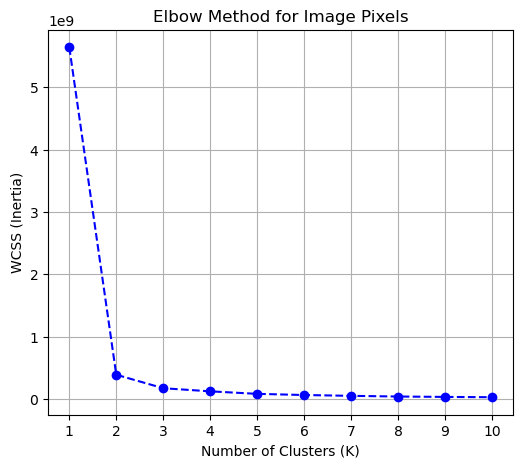

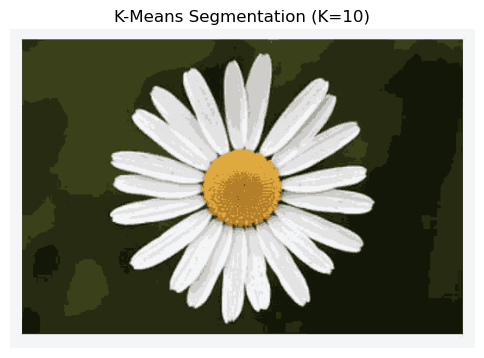

In [14]:
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

# ==========================================
# 1. LOAD AND PREPROCESS IMAGE
# ==========================================
# matplotlib reads images directly as RGB
image = mpimg.imread("image.jpeg")

# Flatten the image into a 2D array of RGB pixels
pixels = image.reshape((-1, 3))
pixels = np.float32(pixels)  # Convert to float for calculation precision

# ==========================================
# 2. CALCULATE WCSS FOR THE ELBOW METHOD
# ==========================================
wcss = []
k_range = range(1, 11)

print("Calculating WCSS for K=1 to 10... Please wait...")
for k in k_range:
    kmeans = KMeans(
        n_clusters=k, init="k-means++", max_iter=300, n_init=10, random_state=42
    )
    kmeans.fit(pixels)
    wcss.append(kmeans.inertia_)

# ==========================================
# 3. PLOT WINDOW 1: ELBOW METHOD GRAPH
# ==========================================
plt.figure(1, figsize=(6, 5))  # Explicitly names this window Figure 1
plt.plot(k_range, wcss, marker="o", linestyle="--", color="b")
plt.title("Elbow Method for Image Pixels")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(k_range)
plt.grid(True)
plt.draw()  # Prepares the window without blocking the script execution

# ==========================================
# 4. PERFORM SEGMENTATION WITH CHOSEN K
# ==========================================
# Choose your K based on the elbow plot break point (e.g., K=3)
optimal_k = 10

print(f"Generating segmentation for K={optimal_k}...")
kmeans_final = KMeans(
    n_clusters=optimal_k,
    init="k-means++",
    max_iter=300,
    n_init=10,
    random_state=42,
)
labels = kmeans_final.fit_predict(pixels)

# Map every pixel back to its corresponding cluster center color
centers = np.uint8(kmeans_final.cluster_centers_)
segmented_pixels = centers[labels.flatten()]
segmented_image = segmented_pixels.reshape(image.shape)

# ==========================================
# 5. PLOT WINDOW 2: SEGMENTED IMAGE
# ==========================================
plt.figure(2, figsize=(6, 5))  # Explicitly names this window Figure 2
plt.imshow(segmented_image)
plt.title(f"K-Means Segmentation (K={optimal_k})")
plt.axis("off")

# ==========================================
# 6. DISPLAY BOTH WINDOWS
# ==========================================
# This opens both windows on your screen simultaneously
plt.show()


Extracting spectral graph embeddings...
Running K-Means on Spectral Embeddings for Elbow Curve...
Generating final segmented matrix using K=100...


c:\anaconda\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:453: UserWarning: Exited at iteration 65 with accuracies 
[1.59186231e-13 6.03883664e-08 7.61123187e-08 1.02304591e-07
 1.84950601e-07 3.89331431e-07 2.67035294e-07 6.57640856e-07
 6.44778939e-07 7.17621832e-07 8.38463566e-07 1.24476029e-06
 1.25852802e-06 1.98955752e-06 2.30068603e-06 3.34313882e-06
 5.11099693e-06 5.17912887e-06 4.89934467e-06 6.48706765e-06
 5.53907960e-07 9.11684674e-07 1.03180472e-06 1.59686657e-06
 1.59728980e-06 2.38811327e-06 2.55067579e-06 3.07343339e-06
 3.92079170e-06 5.11942343e-06 5.29648893e-06 7.91280012e-06
 1.44302660e-06 1.59044472e-06 1.62385157e-06 3.37361078e-06
 2.71308075e-06 4.02621688e-06 4.52996462e-06 6.39094437e-06
 2.84047764e-06 3.57950763e-06 6.80863604e-06 6.90522757e-06
 1.13374387e-05 1.16937506e-05 5.25353785e-06 1.21921393e-05
 5.62372379e-06 9.13934274e-06 5.87002781e-06 7.54495644e-06
 9.12900193e-06 9.92959985e-06 1.20644251e-05 9.61321181e-06
 8.09800024e-06 8.

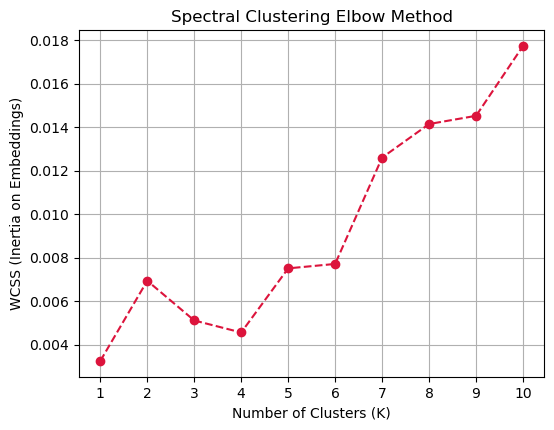

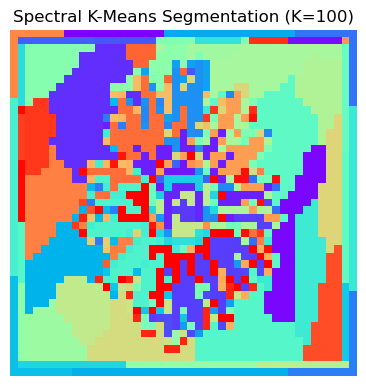

In [ ]:
import cv2
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.manifold import spectral_embedding
from sklearn.preprocessing import minmax_scale

# ==========================================
# 1. LOAD AND PREPROCESS IMAGE 
# ==========================================
orig_image = mpimg.imread("image.jpeg")

# Downsample aggressively to 45x45 to keep the affinity matrix RAM footprint safe
target_grid = (45, 45)
small_image = cv2.resize(orig_image, target_grid, interpolation=cv2.INTER_AREA)
height, width, channels = small_image.shape

# ==========================================
# 2. FEATURE MATRIX STACKING [R, G, B, X, Y]
# ==========================================
flat_colors = small_image.reshape((-1, 3))
scaled_colors = minmax_scale(flat_colors)

x_coords, y_coords = np.meshgrid(np.arange(width), np.arange(height))
flat_coords = np.column_stack((x_coords.ravel(), y_coords.ravel()))
scaled_coords = minmax_scale(flat_coords)

spatial_importance = 0.4
combined_features = np.hstack((scaled_colors, scaled_coords * spatial_importance))

# ==========================================
# 3. GENERATE SPECTRAL EMBEDDINGS (THE FIXED STEP)
# ==========================================
print("Extracting spectral graph embeddings...")

# Use SpectralEmbedding class instead of SpectralClustering to extract features
from sklearn.manifold import SpectralEmbedding

# We set n_components=10 so we have enough feature columns to test K values up to 10
embedding_model = SpectralEmbedding(
    n_components=10, affinity="rbf", gamma=15.0, random_state=42
)

# This correctly extracts the low-dimensional eigenvectors from your 5D array
embeddings = embedding_model.fit_transform(combined_features)

# ==========================================
# 4. CALCULATE WCSS FOR THE ELBOW GRAPH
# ==========================================
wcss = []
k_range = range(1, 11)

print("Running K-Means on Spectral Embeddings for Elbow Curve...")
for k in k_range:
    # Slice the embeddings array to look at the first 'k' structural dimensions
    sub_embedding = embeddings[:, :k]

    kmeans = KMeans(
        n_clusters=k, init="k-means++", max_iter=300, n_init=10, random_state=42
    )
    kmeans.fit(sub_embedding)
    wcss.append(kmeans.inertia_)  # Tracks the WCSS value cleanly


# ==========================================
# 5. GENERATE FINAL SEGMENTATION (e.g., K=4)
# ==========================================
optimal_k = 10
print(f"Generating final segmented matrix using K={optimal_k}...")

final_spectral = SpectralClustering(
    n_clusters=optimal_k,
    affinity="rbf",
    gamma=15.0,
    assign_labels="kmeans",
    random_state=42,
)
labels = final_spectral.fit_predict(combined_features)
segmented_matrix = labels.reshape((height, width))

# ==========================================
# 6. PLOT SEPARATE WINDOW FIGURES
# ==========================================
# Figure 1: The Spectral Elbow Curve
#<layout>
plt.figure(1, figsize=(6, 4.5))
plt.plot(k_range, wcss, marker="o", linestyle="--", color="crimson")
plt.title("Spectral Clustering Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia on Embeddings)")
plt.xticks(k_range)
plt.grid(True)
plt.draw()
#chartPlaceholder(chartDescription="Elbow method graph showing WCSS vs number of clusters for Spectral Clustering showing an inflection point around K=4", results=[])
#</layout>

# Figure 2: The Reshaped Segmented Image Matrix
plt.figure(2, figsize=(6, 4.5))
plt.imshow(segmented_matrix, cmap="rainbow")
plt.title(f"Spectral K-Means Segmentation (K={optimal_k})")
plt.axis("off")

# Render all popup screens onto your monitor display
plt.show()
